# Cymatics plane → line geometry

Debug notebook for **cymatics-geometry**.

## What this pipeline does

1. **Grid** — place points on an **X × Y** lattice (global point counts)
2. **Sources** — up to **8 wave emitters**: corners (SW SE NE NW) + mid-edges (S E N W)
3. **Interference** — each *active* source adds a circular travelling wave; Z is the sum
4. **Release** — the plane is a **surface**: unlocking a source loosens nearby points and that motion **spreads** across the grid
5. **Line** — reconnect displaced points into one continuous serpentine path

## Parameter guide

| Control | Scope | Meaning |
|---|---|---|
| **on / off** | per source | Whether that emitter is enabled (default: corners on) |
| **amp** | per source | Wave strength (starts at 0) |
| **λ** | per source | Crest spacing (0 = no spatial wave) |
| **release** | per source | XY mobility: **0** locked · **1** free under waves · up to **10** = × multiplier. Spreads across the surface |
| **time** | global | Travelling-wave phase |
| **decay** | global | How fast Z amplitude falls with distance |
| **grid X / grid Y** | global | Point counts along X and Y |

All numeric sliders start at **0**. Raise amp + λ for waves; raise release so the whole surface can follow.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

for _name in list(sys.modules):
    if _name == "cymatics_geometry" or _name.startswith("cymatics_geometry."):
        del sys.modules[_name]

from cymatics_geometry.config import PipelineConfig
from cymatics_geometry.pipeline import export_line_obj, run_pipeline
from cymatics_geometry.visualization import (
    show_all_stages_matplotlib,
    show_interactive_line_viewer,
)

print("Ready.")


Ready.


## Static run — inspect every stage

Example with non-zero corner amps/λ so the stage overview is visible.
(The interactive viewer below starts everything at 0.)


Grid: 80×80 (X×Y), side=100.0
Active sources: ['SW', 'SE', 'NE', 'NW']
Amplitudes SW/SE/NE/NW/S/E/N/W: 1.000 / 0.850 / 0.550 / 0.900 / 0.000 / 0.000 / 0.000 / 0.000
frequency=1.000, time=0.000, decay=0.000
line_pattern=serpentine
Stage 1 — flat grid: 6400 points
Stage 2 — sources: ['SW', 'SE', 'NE', 'NW', 'S', 'E', 'N', 'W']
Stage 3 — interference field: z∈[-2.9193, 3.0956]
Stage 4 — displaced points: 6400 (xy released: 0)
Stage 5 — line geometry: 6400 vertices, length=8242.008, cells=1


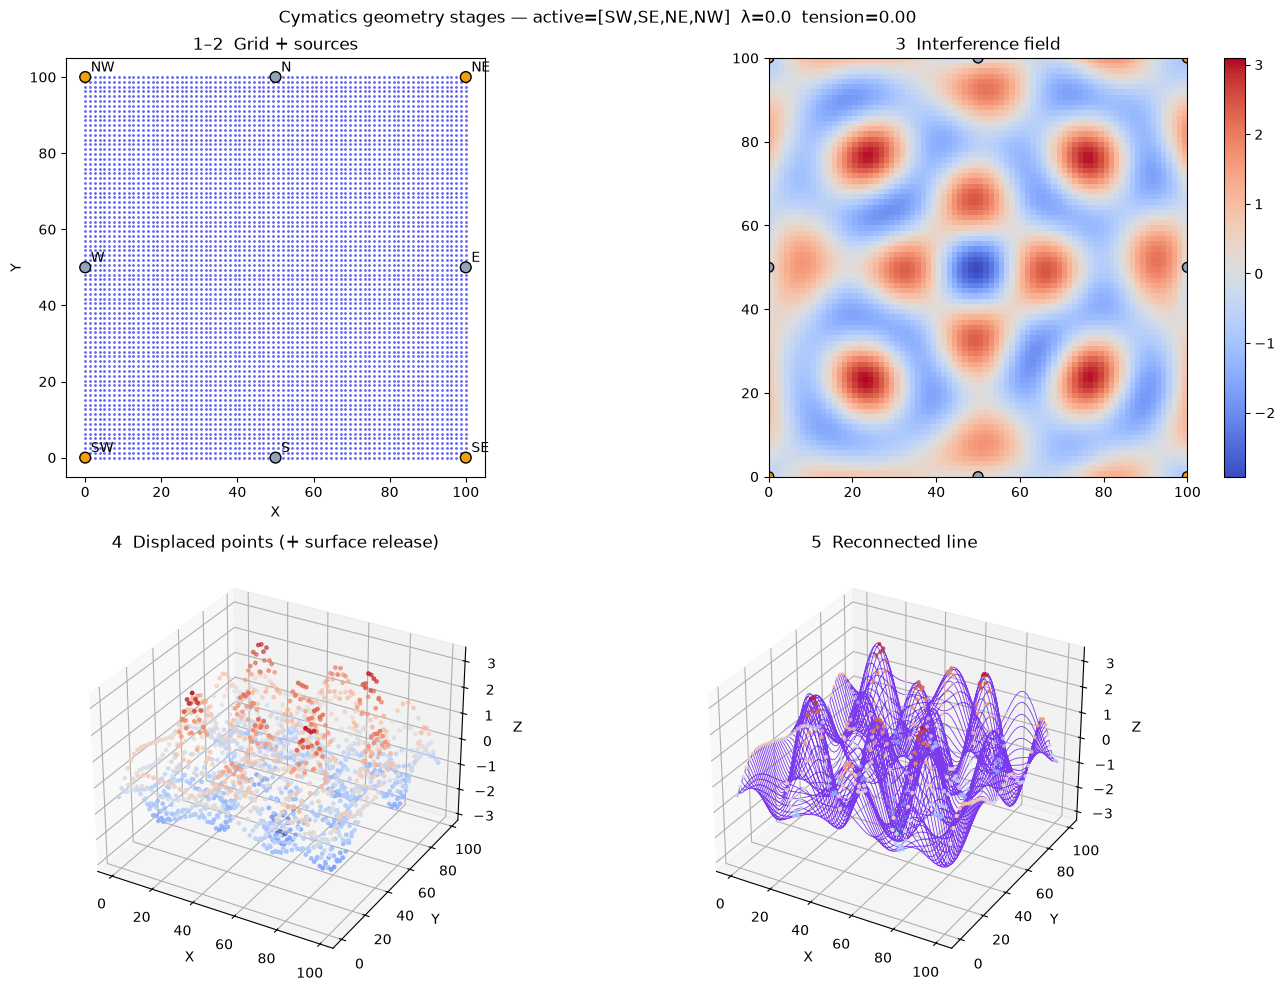

{'point_count': 6400,
 'grid_size': 80,
 'grid_size_x': 80,
 'grid_size_y': 80,
 'displacement_min': -2.9192802994419793,
 'displacement_max': 3.0955752964166283,
 'displacement_mean': -0.026620358637319742,
 'displacement_std': 1.0423844303842738,
 'border_released': 0,
 'xy_released': 0,
 'xy_offset_max': 0.0,
 'polyline_vertices': 6400,
 'polyline_length': 8242.007999821994,
 'amplitudes': [1.0, 0.85, 0.55, 0.9, 0.0, 0.0, 0.0, 0.0],
 'active': [True, True, True, True, False, False, False, False],
 'active_labels': ['SW', 'SE', 'NE', 'NW'],
 'wavelength': 0.0,
 'frequency': 1.0,
 'time': 0.0,
 'boundary_tension': 0.0,
 'release_pace': 0.0,
 'line_pattern': 'serpentine'}

In [2]:
config = PipelineConfig(
    grid_size_x=80,
    grid_size_y=80,
    side_length=100.0,
    amplitude_sw=1.0,
    amplitude_se=0.85,
    amplitude_ne=0.55,
    amplitude_nw=0.9,
    wavelength_sw=25.0,
    wavelength_se=25.0,
    wavelength_ne=25.0,
    wavelength_nw=25.0,
    release_sw=0.0,
    release_se=0.0,
    release_ne=0.0,
    release_nw=0.0,
    active_s=False,
    active_e=False,
    active_n=False,
    active_w=False,
    time=0.0,
    decay=0.0,
    line_pattern="serpentine",
)

result = run_pipeline(config, verbose=True)
show_all_stages_matplotlib(result)
result.stats


## Interactive 3D line

**View left · controls right.**

Use the **source dropdown** to edit one emitter at a time (active / amp / λ / release).
Global **grid X** and **grid Y** set how many points are along each axis.
All sliders start at **0**.

Try: SW → amp `1` → λ `25` → release `2` — the corner loosens and the surface around it should move too.


In [3]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

for _name in list(sys.modules):
    if _name == "cymatics_geometry" or _name.startswith("cymatics_geometry."):
        del sys.modules[_name]

from cymatics_geometry.config import PipelineConfig
from cymatics_geometry.visualization import show_interactive_line_viewer

show_interactive_line_viewer(
    PipelineConfig(grid_size_x=60, grid_size_y=60),
    amplitude_max=10.0,
)


    'data': [{'hoverinfo': 'skip',
              'line': {'color': '#64748b', 'd…

## Export line geometry

Writes the current `result` line mesh to `exports/` as an OBJ.


In [ ]:
if "result" not in globals():
    result = run_pipeline(
        PipelineConfig(grid_size_x=60, grid_size_y=60),
        verbose=False,
    )

export_dir = ROOT / "exports"
path = export_line_obj(result, export_dir)
print("Wrote", path)
